In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [117]:
df = pd.read_csv("user_data.csv")

# Agregamos la tasa de retencion
df["retention_rate"] = (
    df["usuarios_retenidos"]
    / df["usuarios_activos"].shift(1)
    * 100
).round(2)

### Cálculo de tasas de retención

In [118]:
df["growth_rate_nuevos"] = (
    df["nuevos_usuarios"].pct_change() * 100
).round(2)

df.head()

,mes,nuevos_usuarios,usuarios_totales,usuarios_activos,usuarios_retenidos,retention_rate,growth_rate_nuevos
0,1,94,94,61,NaN,NaN,NaN
1,2,122,216,131,45.0,73.77,29.79
2,3,111,327,189,94.0,71.76,-9.02
3,4,170,497,284,169.0,89.42,53.15
4,5,162,659,306,199.0,70.07,-4.71


Text(0, 0.5, 'Cantidad de usuarios nuevos')

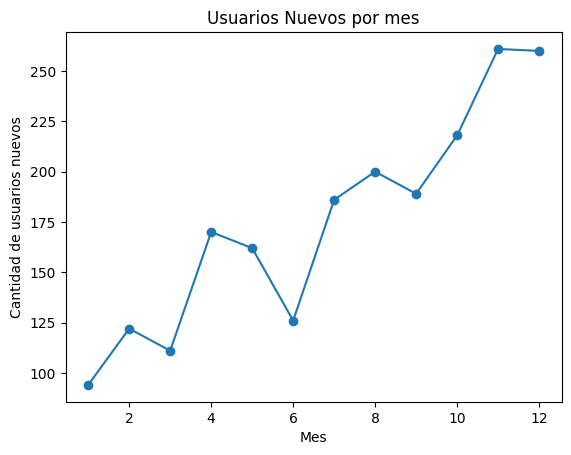

In [119]:
plt.plot(df["mes"], df["nuevos_usuarios"], marker='o')
plt.title("Usuarios Nuevos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de usuarios nuevos")

In [120]:
X = df[["mes"]]
y = df["nuevos_usuarios"]

model = LinearRegression()

model.fit(X, y)

proximos_meses = pd.DataFrame({
    "mes": [13, 14, 15]
})

proyeccion = model.predict(proximos_meses)
# print(proyeccion)

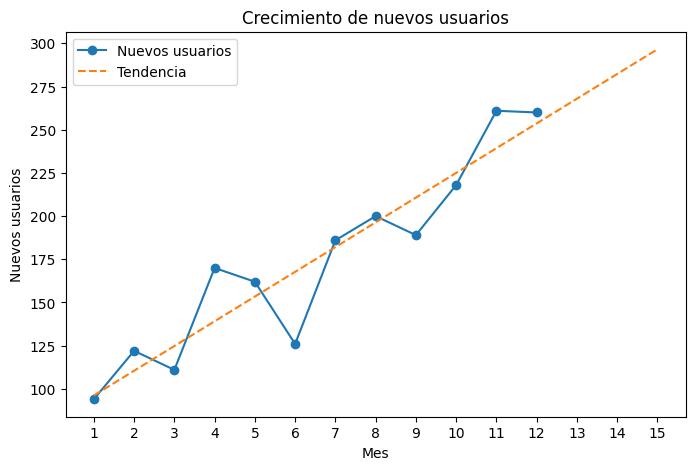

In [121]:
# plt.figure(figsize=(10, 6))

plt.figure(figsize=(8, 5))

# Datos históricos
plt.plot(
    df["mes"],
    df["nuevos_usuarios"],
    marker="o",
    label="Nuevos usuarios"
)

# Línea de tendencia extendida hasta el mes 15
meses_tendencia = pd.DataFrame({
    "mes": range(1, 16)
})

tendencia = model.predict(meses_tendencia)

plt.plot(
    meses_tendencia["mes"],
    tendencia,
    linestyle="--",
    label="Tendencia"
)

plt.xlabel("Mes")
plt.ylabel("Nuevos usuarios")
plt.title("Crecimiento de nuevos usuarios")
plt.xticks(range(1, 16))
plt.legend()

plt.show()

In [122]:
# Guardamos los datos de proyeccion de la tendencia
# en un DataFrame para poder graficar con streamlit.
d = {"mes": range(1,16) , "proyeccion":tendencia}
df_proyeccion = pd.DataFrame(data=d)

<Figure size 800x500 with 0 Axes>

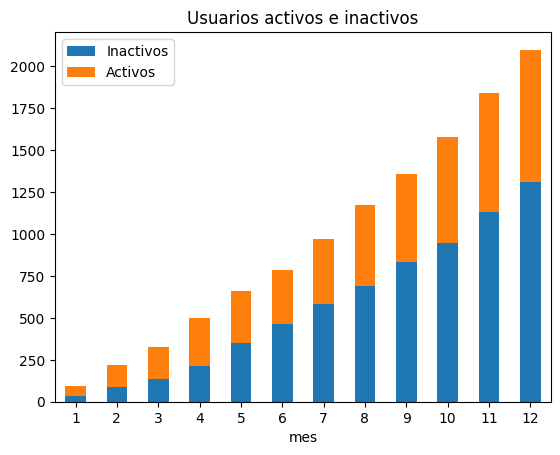

In [123]:
df["usuarios_inactivos"] = df["usuarios_totales"] - df["usuarios_activos"]

plt.figure(figsize=(8, 5))
ax = df.plot(
    x="mes",
    y=["usuarios_inactivos", "usuarios_activos"],
    kind="bar",
    stacked=True,
    # legend=False,
    legend=("Activos", "Inactivos")
)
plt.xticks(rotation=0)
plt.title("Usuarios activos e inactivos")
ax.legend(["Inactivos", "Activos"])
plt.show()

Text(0, 0.5, 'Tasa de retención (%)')

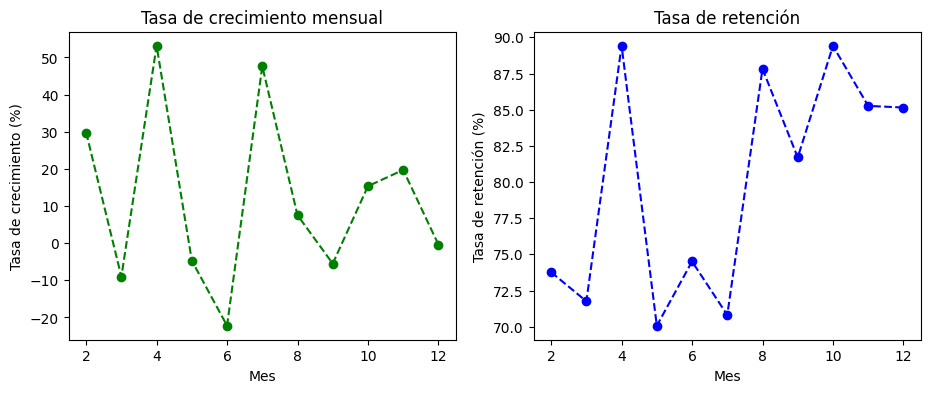

In [124]:
figure, axes = plt.subplots(ncols=2, figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(
    df["mes"],
    df["growth_rate_nuevos"],
    "--g", marker="o"
    # ax=axes[0]
    )

plt.subplot(1,2,2)
plt.plot(
    df["mes"],
    df["retention_rate"],
    "--b", marker="o"
)

axes[0].set_title('Tasa de crecimiento mensual')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Tasa de crecimiento (%)')


axes[1].set_title('Tasa de retención')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Tasa de retención (%)')

In [125]:
# Guardamos el dataframe con los datos extra para graficar con streamlit

with pd.ExcelWriter("user_data_streamlit.xlsx") as writer:
    df.to_excel(writer, sheet_name="datos", index=False)
    df_proyeccion.to_excel(
        writer,
        sheet_name="proyeccion",
        index=False
    )